# Threshold Regression — Geometric Object Images
**Goal:** Given a grayscale image of geometric objects on a flat background, predict the optimal binary threshold value (0–255) for OpenCV segmentation.

**Pipeline:** CRISP-DM
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment (inference demo)

## 0. Imports & Config

In [2]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import seaborn as sns

matplotlib.rcParams['axes.labelsize'] = 13
matplotlib.rcParams['xtick.labelsize'] = 11
matplotlib.rcParams['ytick.labelsize'] = 11

IMAGES_DIR = "images"          # <-- ham fotoğrafların bulunduğu klasör
LABELED_DIR = "labeled"        # <-- threshold alınmış fotoğrafların bulunduğu klasör
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

RANDOM_STATE = 42 #otostopçunun galaksi rehberinden :)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, name + ".png"), dpi=150)
    plt.show()

print("Setup complete.")

Setup complete.


## 1. Data Loading
Threshold labels are encoded in the labeled image filenames: `{frame_name}_{threshold}.png`
I've used a python script for labeling. Actually there is a automated threshold function but I find it weak and wanted to make my own.

In [3]:
def parse_labeled_dir(labeled_dir):
    """
    labeled_dir içindeki dosya isimlerinden (frameAdı_thresholdDeğeri.png)
    frame adı ve threshold değerini parse eder.
    """
    pattern = re.compile(r'^(.+)_(\d+)\.png$', re.IGNORECASE)
    records = []
    for fname in os.listdir(labeled_dir):
        m = pattern.match(fname)
        if m:
            frame_name = m.group(1)       # örn: frame_011
            threshold  = int(m.group(2))  # örn: 194
            records.append({"frame": frame_name, "threshold": threshold, "labeled_file": fname})
    return pd.DataFrame(records).sort_values("frame").reset_index(drop=True)

labels_df = parse_labeled_dir(LABELED_DIR)
print(f"Toplam etiketli örnek: {len(labels_df)}")
labels_df.head(10)

Toplam etiketli örnek: 142


,frame,threshold,labeled_file
0,frame1_000,74,frame1_000_74.png
1,frame1_001,74,frame1_001_74.png
2,frame1_002,68,frame1_002_68.png
3,frame1_010,74,frame1_010_74.png
4,frame1_011,197,frame1_011_197.png
5,frame1_012,188,frame1_012_188.png
6,frame1_013,182,frame1_013_182.png
7,frame1_014,197,frame1_014_197.png
8,frame1_015,203,frame1_015_203.png
9,frame1_016,191,frame1_016_191.png


## 2. Feature Extraction
Raw pixels → statistical image features.

In [4]:
def extract_features(img_path):
    """
    Grayscale görüntüden istatistiksel özellikler çıkarır.
    Geri döndürür: dict
    """
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Görüntü bulunamadı: {img_path}")

    flat = img.flatten().astype(np.float32)

    # --- Temel istatistikler ---
    mean   = flat.mean()
    std    = flat.std()
    median = np.median(flat)
    skew   = float(pd.Series(flat).skew())
    kurt   = float(pd.Series(flat).kurt()) 

    # --- Yüzdelikler ---
    p10, p25, p75, p90, p95, p99 = np.percentile(flat, [10, 25, 75, 90, 95, 99])

    # --- Histogram tabanlı ---
    hist, _ = np.histogram(flat, bins=32, range=(0, 256))
    hist_norm = hist / hist.sum()
    dominant_bin = int(np.argmax(hist_norm))  # en yoğun piksel bandı

    # --- Otsu threshold (referans özellik) ---
    otsu_val, _ = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # --- Parlak piksel oranları ---
    bright_ratio_200 = (flat > 200).mean()
    bright_ratio_150 = (flat > 150).mean()
    bright_ratio_100 = (flat > 100).mean()

    features = {
        "mean": mean,
        "std": std,
        "median": median,
        "skewness": skew,
        "kurtosis": kurt,
        "p10": p10, "p25": p25, "p75": p75,
        "p90": p90, "p95": p95, "p99": p99,
        "dominant_bin": dominant_bin,
        "otsu": otsu_val,
        "bright_ratio_100": bright_ratio_100,
        "bright_ratio_150": bright_ratio_150,
        "bright_ratio_200": bright_ratio_200,
    }
    return features

# Tüm veri setine uygula
rows = []
missing = []
for _, row in labels_df.iterrows():
    img_path = os.path.join(IMAGES_DIR, row["frame"] + ".png")
    try:
        feats = extract_features(img_path)
        feats["threshold"] = row["threshold"]
        rows.append(feats)
    except FileNotFoundError:
        missing.append(row["frame"])

if missing:
    print(f"UYARI: {len(missing)} resim bulunamadı: {missing[:5]}")

df = pd.DataFrame(rows)
print(f"Feature matrix: {df.shape}")
df.head()

Feature matrix: (142, 17)


,mean,std,median,skewness,kurtosis,p10,p25,p75,p90,p95,p99,dominant_bin,otsu,bright_ratio_100,bright_ratio_150,bright_ratio_200,threshold
0,121.475250,24.241957,123.0,-1.000694,3.159675,95.0,107.0,137.0,152.0,158.0,166.0,16,119.0,0.830749,0.115781,0.000000,74
1,123.391197,21.949905,124.0,-1.058461,3.938221,98.0,110.0,138.0,150.0,158.0,165.0,15,120.0,0.883288,0.095508,0.000000,74
2,123.433167,21.750601,123.0,-1.213205,4.844625,101.0,110.0,138.0,150.0,157.0,162.0,15,122.0,0.905146,0.094961,0.000000,68
3,122.601990,20.381248,123.0,-0.022359,-0.275982,95.0,108.0,137.0,151.0,157.0,165.0,16,121.0,0.840850,0.108577,0.000000,74
4,124.056938,34.767750,117.0,1.540637,3.456942,88.0,101.0,140.0,164.0,176.0,254.0,13,139.0,0.764609,0.187536,0.035661,197


## 3. Data Understanding — EDA

In [5]:
print(df.describe().T.to_string())

                  count        mean        std         min         25%         50%         75%         max
mean              142.0  121.377548  13.399264   50.035572  113.646545  122.664413  125.686096  160.428131
std               142.0   30.485189   9.992565    3.964035   23.787797   32.162104   36.832175   48.147003
median            142.0  120.732391  19.089901   44.000000  110.000000  119.000000  129.750000  167.000000
skewness          142.0   -0.013688   3.144086   -9.348988   -1.851761    1.190162    1.680614    4.340666
kurtosis          142.0   12.204950  21.877407   -0.275982    2.915482    3.753773   10.692317  113.250267
p10               142.0   86.218310  26.698239   19.000000   81.000000   88.000000   97.000000  145.000000
p25               142.0  109.253521  19.230383   33.000000   97.000000  104.000000  123.000000  155.000000
p75               142.0  134.563380  19.085647   58.000000  126.000000  137.000000  140.750000  181.000000
p90               142.0  149.908451  

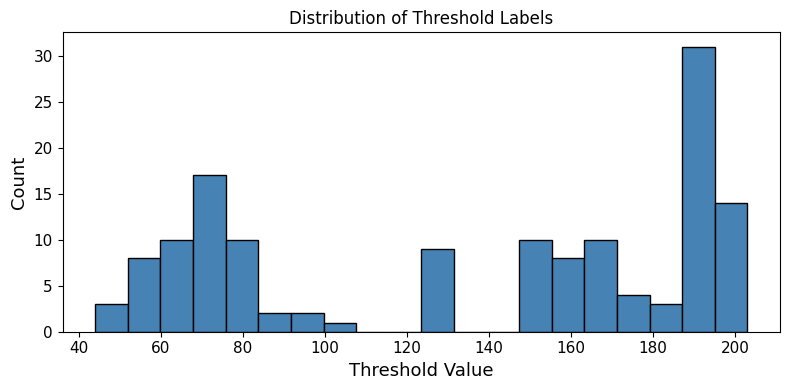

In [6]:
# Threshold dağılımı
plt.figure(figsize=(8, 4))
plt.hist(df["threshold"], bins=20, edgecolor="black", color="steelblue")
plt.xlabel("Threshold Value")
plt.ylabel("Count")
plt.title("Distribution of Threshold Labels")
save_fig("threshold_distribution")

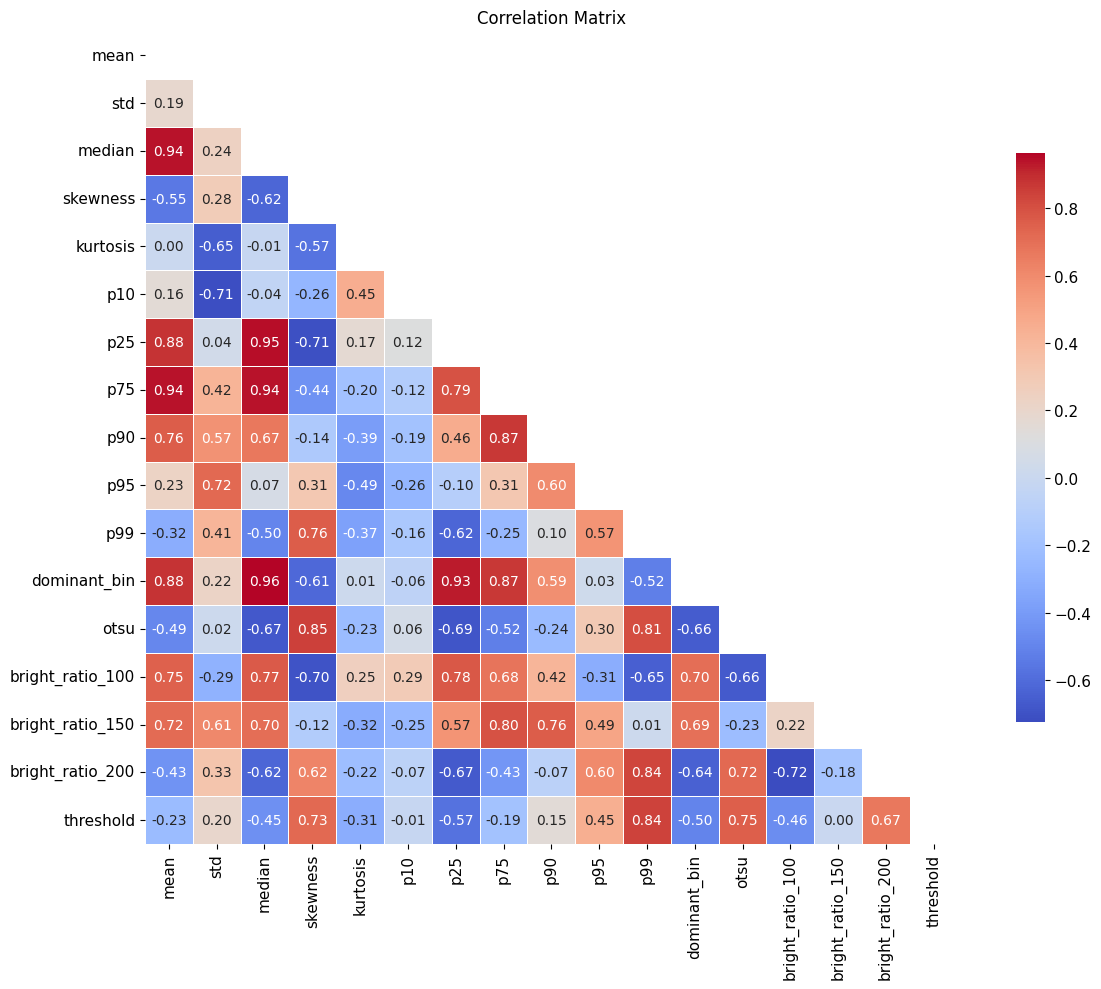

In [7]:
# Korelasyon matrisi
plt.figure(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation Matrix")
save_fig("correlation_matrix")

In [8]:
# En yüksek korelasyonlu özellikler (threshold ile)
corr_with_target = df.corr()["threshold"].drop("threshold").sort_values(key=abs, ascending=False)
print("Threshold ile korelasyon:")
print(corr_with_target.to_string())

Threshold ile korelasyon:
p99                 0.839019
otsu                0.752556
skewness            0.725292
bright_ratio_200    0.670914
p25                -0.574819
dominant_bin       -0.504009
bright_ratio_100   -0.462913
median             -0.448244
p95                 0.445426
kurtosis           -0.311300
mean               -0.232405
std                 0.195703
p75                -0.193833
p90                 0.147812
p10                -0.014265
bright_ratio_150    0.000152


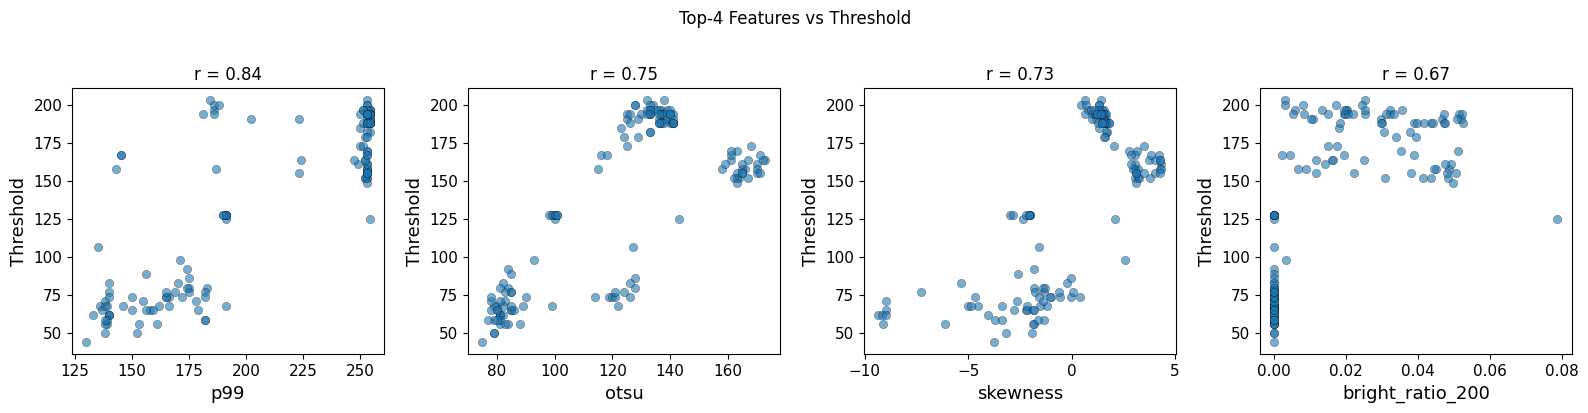

In [9]:
# En güçlü 4 özelliğin scatter plot'u
top4 = corr_with_target.head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, top4):
    ax.scatter(df[feat], df["threshold"], alpha=0.6, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel("Threshold")
    ax.set_title(f"r = {df[feat].corr(df['threshold']):.2f}")
plt.suptitle("Top-4 Features vs Threshold", y=1.02)
save_fig("scatter_top4_features")

## 4. Data Preparation

In [10]:
FEATURE_COLS = [c for c in df.columns if c != "threshold"]
TARGET_COL   = "threshold"

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y range: [{y.min()}, {y.max()}]")

X shape: (142, 16)
y shape: (142,)
y range: [44, 203]


In [11]:
# --- Hold-out split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# --- Three-way split (60/20/20) ---
X_trainval, X_test3, y_trainval, y_test3 = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train3, X_val3, y_train3, y_val3 = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE  # 0.25 × 0.8 = 0.2
)

print(f"Hold-out  → train: {X_train.shape[0]}, test: {X_test.shape[0]}")
print(f"Three-way → train: {X_train3.shape[0]}, val: {X_val3.shape[0]}, test: {X_test3.shape[0]}")

Hold-out  → train: 113, test: 29
Three-way → train: 84, val: 29, test: 29


## 5. Modeling
5 algorithms, all wrapped in a `Pipeline(StandardScaler → model)` for fair comparison.

In [12]:
def make_pipeline(model):
    return Pipeline([("scaler", StandardScaler()), ("model", model)])

models = {
    "LinearRegression":    make_pipeline(LinearRegression()),
    "DecisionTree":        make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    "RandomForest":        make_pipeline(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)),
    "KNN":                 make_pipeline(KNeighborsRegressor(n_neighbors=5)),
    "SVR":                 make_pipeline(SVR(kernel="rbf", C=100, gamma="scale")),
}

In [13]:
# --- Cross-Validation (5-fold, tüm veri) ---
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=kf, scoring="neg_mean_absolute_error")
    cv_results[name] = {"cv_mae_mean": -scores.mean(), "cv_mae_std": scores.std()}
    print(f"{name:22s} CV MAE: {-scores.mean():.2f} ± {scores.std():.2f}")

LinearRegression       CV MAE: 18.85 ± 4.62
DecisionTree           CV MAE: 7.51 ± 1.95
RandomForest           CV MAE: 7.56 ± 2.10
KNN                    CV MAE: 8.61 ± 1.13
SVR                    CV MAE: 9.46 ± 1.42


In [14]:
# --- Hold-out evaluation ---
holdout_results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    holdout_results[name] = {
        "MAE":  mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2":   r2_score(y_test, preds),
    }

holdout_df = pd.DataFrame(holdout_results).T.round(3)
print("=== Hold-out Results ===")
print(holdout_df.to_string())

=== Hold-out Results ===
                     MAE    RMSE     R2
LinearRegression  14.535  20.281  0.864
DecisionTree       5.690   8.393  0.977
RandomForest       5.255   7.599  0.981
KNN                6.745  10.652  0.962
SVR                8.203  13.191  0.942


In [15]:
# --- Three-way split evaluation ---
threeway_results = {}
for name, pipe in models.items():
    pipe.fit(X_train3, y_train3)
    val_preds  = pipe.predict(X_val3)
    test_preds = pipe.predict(X_test3)
    threeway_results[name] = {
        "Val_MAE":   mean_absolute_error(y_val3, val_preds),
        "Val_R2":    r2_score(y_val3, val_preds),
        "Test_MAE":  mean_absolute_error(y_test3, test_preds),
        "Test_R2":   r2_score(y_test3, test_preds),
    }

threeway_df = pd.DataFrame(threeway_results).T.round(3)
print("=== Three-way Split Results ===")
print(threeway_df.to_string())

=== Three-way Split Results ===
                  Val_MAE  Val_R2  Test_MAE  Test_R2
LinearRegression   18.500   0.808    12.459    0.886
DecisionTree       16.345   0.684    11.276    0.757
RandomForest       16.902   0.627    11.894    0.752
KNN                13.076   0.874     6.683    0.961
SVR                14.428   0.802     9.132    0.889


## 6. Evaluation — Visualizations

In [16]:
# Karşılaştırmalı metrik tablosu
summary = holdout_df.copy()
summary["CV_MAE"] = pd.Series({k: round(v["cv_mae_mean"], 3) for k, v in cv_results.items()})
summary["CV_MAE_std"] = pd.Series({k: round(v["cv_mae_std"], 3) for k, v in cv_results.items()})
print("=== Full Comparison Table ===")
print(summary.to_string())

=== Full Comparison Table ===
                     MAE    RMSE     R2  CV_MAE  CV_MAE_std
LinearRegression  14.535  20.281  0.864  18.846       4.620
DecisionTree       5.690   8.393  0.977   7.512       1.950
RandomForest       5.255   7.599  0.981   7.560       2.101
KNN                6.745  10.652  0.962   8.615       1.127
SVR                8.203  13.191  0.942   9.462       1.424


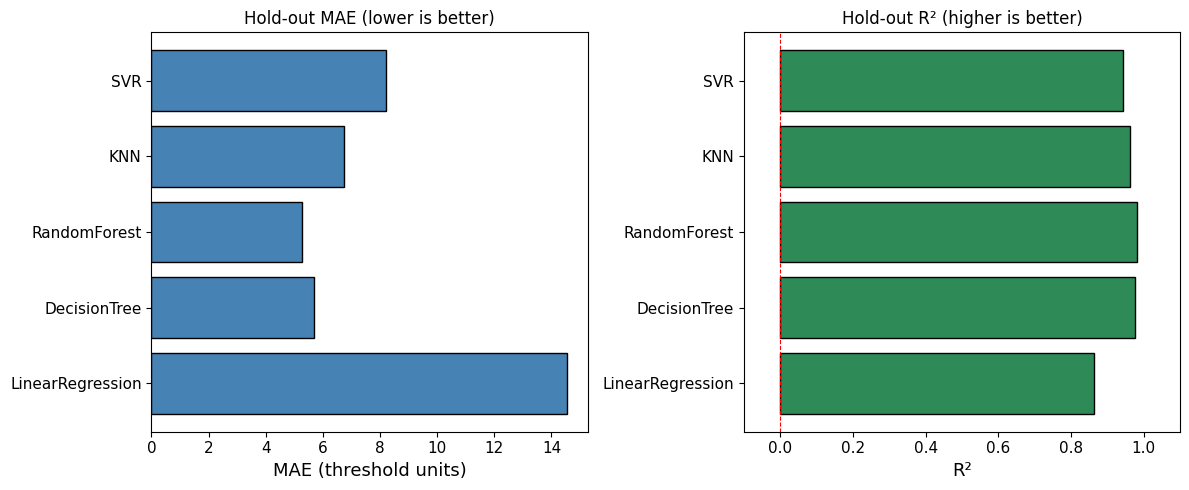

In [17]:
# MAE karşılaştırma bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

names = list(holdout_results.keys())
mae_vals = [holdout_results[n]["MAE"] for n in names]
r2_vals  = [holdout_results[n]["R2"]  for n in names]

axes[0].barh(names, mae_vals, color="steelblue", edgecolor="black")
axes[0].set_xlabel("MAE (threshold units)")
axes[0].set_title("Hold-out MAE (lower is better)")

axes[1].barh(names, r2_vals, color="seagreen", edgecolor="black")
axes[1].set_xlabel("R²")
axes[1].set_title("Hold-out R² (higher is better)")
axes[1].set_xlim(-0.1, 1.1)
axes[1].axvline(0, color="red", linestyle="--", linewidth=0.8)

save_fig("model_comparison")

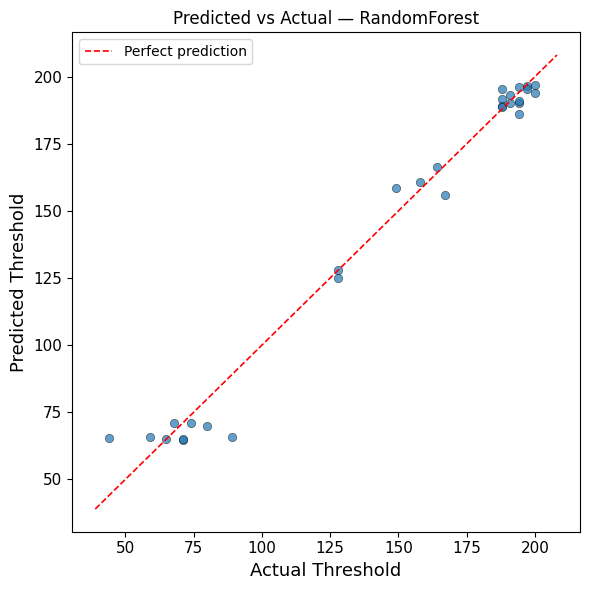

In [18]:
# En iyi modelin Predicted vs Actual grafiği
best_model_name = min(holdout_results, key=lambda k: holdout_results[k]["MAE"])
best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_train)
y_pred_best = best_pipe.predict(X_test)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, edgecolors='k', linewidths=0.4)
lim = [min(y.min(), y_pred_best.min()) - 5, max(y.max(), y_pred_best.max()) + 5]
plt.plot(lim, lim, 'r--', linewidth=1.2, label="Perfect prediction")
plt.xlabel("Actual Threshold")
plt.ylabel("Predicted Threshold")
plt.title(f"Predicted vs Actual — {best_model_name}")
plt.legend()
save_fig("predicted_vs_actual")

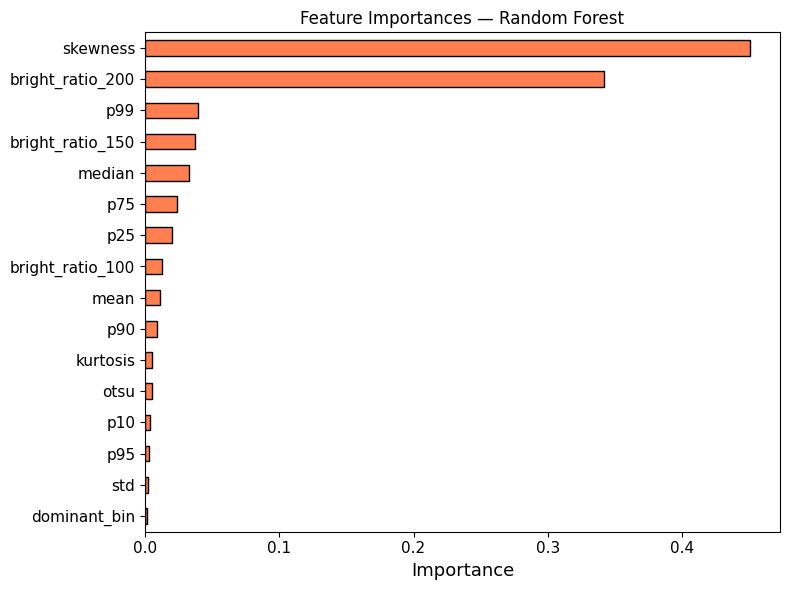

In [19]:
# Feature Importance (RandomForest)
rf_pipe = models["RandomForest"]
rf_pipe.fit(X_train, y_train)
importances = rf_pipe.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_imp.plot(kind="barh", color="coral", edgecolor="black")
plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance")
save_fig("feature_importance")

## 7. Inference Demo
Tek bir görüntü üzerinden threshold tahmini yapılır ve görselleştirilir.

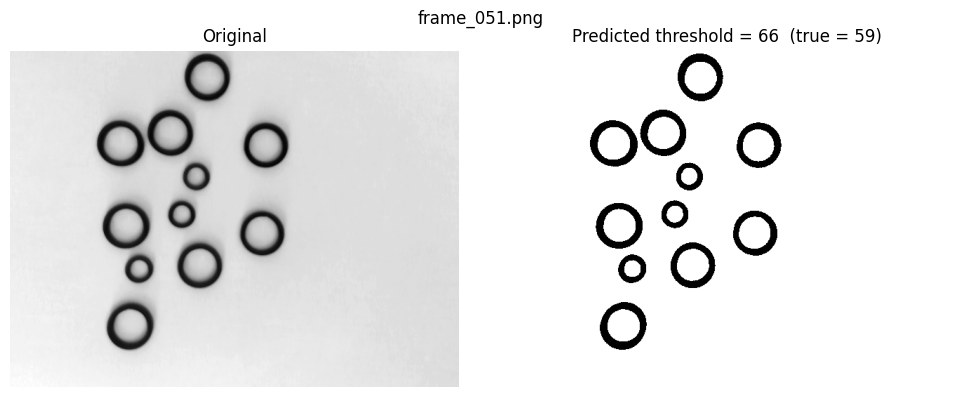

In [20]:
def predict_threshold(img_path, pipeline):
    feats = extract_features(img_path)
    X_new = np.array([list(feats.values())])
    return int(round(pipeline.predict(X_new)[0]))

def show_inference(img_path, pipeline, true_threshold=None):
    pred_thresh = predict_threshold(img_path, pipeline)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    _, thresh_img = cv2.threshold(img, pred_thresh, 255, cv2.THRESH_BINARY)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    title = f"Predicted threshold = {pred_thresh}"
    if true_threshold is not None:
        title += f"  (true = {true_threshold})"
    axes[1].imshow(thresh_img, cmap="gray")
    axes[1].set_title(title)
    axes[1].axis("off")

    plt.suptitle(os.path.basename(img_path))
    save_fig("inference_demo")

# Örnek kullanım — bir resim yolunu ve gerçek threshold'unu yaz
DEMO_IMG   = os.path.join(IMAGES_DIR, "frame_051.png")
DEMO_TRUE  = 59  # dosya adından bilinen gerçek değer

show_inference(DEMO_IMG, best_pipe, true_threshold=DEMO_TRUE)